<a href="https://colab.research.google.com/github/lucmedrado/mlp-TEND-NCIAS/blob/main/mlp_tend.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Objetivo e integrantes

**Objetivo:** Implementar uma rede neural Multilayer Perceptron (MLP) do zero com NumPy para classificar frutos de café em cinco categorias de maturação: seco, passado do ponto, maduro, semimaduro e verde. A rede utiliza características de cor extraídas das regiões dos frutos delimitadas pelas anotações da base. O trabalho compara hiperparâmetros e avalia o desempenho por meio de métricas e gráficos.

**Integrantes:**

* Lucas Medrado Santos
* Álvaro Brandão Neto
* João Pedro Mafaldo de Paula


### 2. Descrição da base de dados

Foi utilizada a base **Coffee Fruit Maturity**, disponibilizada no [Kaggle](https://www.kaggle.com/datasets/cienciacafeto/coffee-fruit-maturity), contendo 859 fotografias de frutos de café e anotações que delimitam seus contornos. Os frutos estão classificados em cinco categorias: seco, passado do ponto, maduro, semimaduro e verde. Uma fotografia pode conter vários frutos.

Foi preservada a divisão original da base. Após o processamento das anotações, foram obtidos:

| Conjunto  | Quantidade de frutos |
| --------- | -------------------: |
| Treino    |                7.483 |
| Validação |                2.411 |
| Teste     |                1.149 |
| **Total** |           **11.043** |

Para cada fruto, foram extraídas seis características: as médias e os desvios-padrão dos canais vermelho, verde e azul (RGB), considerando apenas os pixels dentro do contorno anotado. Essas características constituem as entradas da MLP e foram padronizadas utilizando parâmetros calculados exclusivamente no conjunto de treino.

A base apresenta desequilíbrio entre as classes, com predominância de frutos verdes. Por isso, a avaliação utiliza acurácia, precisão, recall e F1 por classe, além do F1 macro.


### 3. Carregamento e visualização das imagens

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


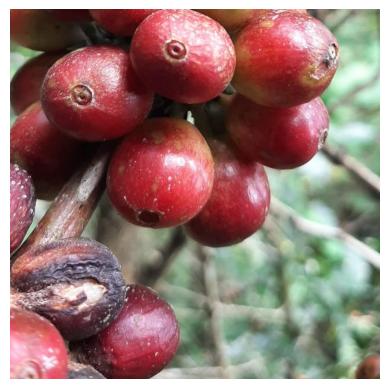

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 5
names: ['dry', 'overripe', 'ripe', 'semi_ripe', 'unripe']

roboflow:
  workspace: ciencia-cafeto
  project: coffee-fruit-maturity-befkg
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/ciencia-cafeto/coffee-fruit-maturity-befkg/dataset/1
Exemplo de anotação: 3 0.2758064515625 0.6233870968749999 0.2822580640625 0.6045698921875 0.2844086015625 0.586290321875 0.2838709671875 0.56532258125 0.275 0.5564516125 0.2513440859375 0.54462365625 0.24193548437499998 0.5352150531250001 0.2311827953125 0.519086021875 0.2220430109375 0.49112903281250003 0.2215053765625 0.45940860156249996 0.2115591390625 0.450537634375 0.184139784375 0.43387096718749996 0.1610215046875 0.4274193546875 0.126612903125 0.4274193546875 0.10080645156250001 0.4354838703125 0.081989246875 0.44784946249999996 0.0661290328125 0.46532258125 0.05967741875 0.474462365625 0.05 0.5002688171874999 0.048387096875 0.5411290328125 0.0505376343

In [18]:
from google.colab import drive
from pathlib import Path
import zipfile
from PIL import Image
import matplotlib.pyplot as plt

# Conectar o Google Drive e extrair a base de dados.
drive.mount("/content/drive")

arquivo_zip = "/content/drive/MyDrive/projeto_mlp_cafe/coffee-fruit-maturity.zip"
pasta_dados = Path("/content/dados_cafe")

with zipfile.ZipFile(arquivo_zip) as pacote:
    pacote.extractall(pasta_dados)

# Exibir um exemplo de imagem.
imagens = sorted(pasta_dados.rglob("*.jpg"))

with Image.open(imagens[0]) as imagem:
    plt.imshow(imagem.convert("RGB"))
    plt.axis("off")
    plt.show()

# Exibir a configuração e as classes da base.
configuracao = next(pasta_dados.rglob("*.yaml"))
print(configuracao.read_text(encoding="utf-8"))

# Exibir um exemplo de anotação.
nomes_imagens = {imagem.stem for imagem in imagens}

for arquivo in pasta_dados.rglob("*.txt"):
    if arquivo.stem in nomes_imagens:
        texto = arquivo.read_text(encoding="utf-8").strip()
        if texto:
            print("Exemplo de anotação:", texto.splitlines()[0])
            break

### 4. Separação dos dados e extração de características

In [19]:
import numpy as np
from PIL import ImageDraw
from sklearn.preprocessing import StandardScaler

classes = ["Seco", "Passado do ponto", "Maduro", "Semimaduro", "Verde"]

def preparar_dados(divisao):
    # Localizar o diretório de imagens correspondente.
    pasta = next(pasta_dados.rglob(f"{divisao}/images"))
    entradas, respostas = [], []

    for foto in sorted(pasta.glob("*.jpg")):
        anotacao = pasta.parent / "labels" / f"{foto.stem}.txt"

        if not anotacao.exists():
            continue

        with Image.open(foto) as imagem:
            imagem = imagem.convert("RGB")
            largura, altura = imagem.size
            cores = np.asarray(imagem) / 255.0

        for linha in anotacao.read_text().splitlines():
            if not linha.strip():
                continue

            valores = list(map(float, linha.split()))
            classe = int(valores[0])

            # Converter coordenadas do contorno para o formato da imagem.
            pontos = np.array(valores[1:]).reshape(-1, 2)
            pontos = pontos * [largura, altura]

            # Criar máscara para os pixels pertencentes ao fruto.
            mascara = Image.new("L", (largura, altura), 0)
            ImageDraw.Draw(mascara).polygon(
                [tuple(ponto) for ponto in pontos], fill=1
            )

            pixels = cores[np.array(mascara, dtype=bool)]

            if len(pixels) == 0:
                continue

            # Extração de seis características: médias e desvios-padrão dos canais RGB.
            caracteristicas = np.concatenate([
                pixels.mean(axis=0),
                pixels.std(axis=0)
            ])

            entradas.append(caracteristicas)
            respostas.append(classe)

    return np.array(entradas), np.array(respostas, dtype=int)


# Utilizar os conjuntos de dados originais.
X_treino, y_treino = preparar_dados("train")
X_validacao, y_validacao = preparar_dados("valid")
X_teste, y_teste = preparar_dados("test")

# Padronizar os dados com base no conjunto de treino.
escala = StandardScaler()
X_treino = escala.fit_transform(X_treino)
X_validacao = escala.transform(X_validacao)
X_teste = escala.transform(X_teste)

print("Frutos de treino:", len(y_treino))
print("Frutos de validação:", len(y_validacao))
print("Frutos de teste:", len(y_teste))
print("Características por fruto:", X_treino.shape[1])

Frutos de treino: 7483
Frutos de validação: 2411
Frutos de teste: 1149
Características por fruto: 6


### 5. Implementação da MLP com NumPy

In [20]:
class MLP:
    def __init__(self, camadas, taxa_aprendizado=0.01, momento=0.9):
        self.taxa = taxa_aprendizado
        self.momento = momento
        rng = np.random.default_rng(42)

        # Inicializar pesos e vieses para cada camada.
        self.pesos = [
            rng.normal(0, np.sqrt(2 / entrada), (entrada, saida))
            for entrada, saida in zip(camadas[:-1], camadas[1:])
        ]
        self.vieses = [np.zeros((1, n)) for n in camadas[1:]]

        # Inicializar variáveis para o cálculo do momento.
        self.vel_pesos = [np.zeros_like(p) for p in self.pesos]
        self.vel_vieses = [np.zeros_like(v) for v in self.vieses]

    def forward(self, X):
        self.ativacoes = [X]

        for i, (peso, vies) in enumerate(zip(self.pesos, self.vieses)):
            z = self.ativacoes[-1] @ peso + vies

            if i == len(self.pesos) - 1:
                # Função de ativação Softmax para a camada de saída.
                exp = np.exp(z - z.max(axis=1, keepdims=True))
                saida = exp / exp.sum(axis=1, keepdims=True)
            else:
                # Função de ativação ReLU para as camadas ocultas.
                saida = np.maximum(0, z)

            self.ativacoes.append(saida)

        return self.ativacoes[-1]

    def backward(self, y):
        n = len(y)
        erro = self.ativacoes[-1].copy()
        erro[np.arange(n), y] -= 1
        erro /= n

        for i in reversed(range(len(self.pesos))):
            grad_peso = self.ativacoes[i].T @ erro
            grad_vies = erro.sum(axis=0, keepdims=True)

            # Propagar o erro para a camada anterior.
            if i > 0:
                erro_anterior = (
                    (erro @ self.pesos[i].T)
                    * (self.ativacoes[i] > 0)
                )

            self.vel_pesos[i] = (
                self.momento * self.vel_pesos[i]
                - self.taxa * grad_peso
            )
            self.vel_vieses[i] = (
                self.momento * self.vel_vieses[i]
                - self.taxa * grad_vies
            )

            self.pesos[i] += self.vel_pesos[i]
            self.vieses[i] += self.vel_vieses[i]

            if i > 0:
                erro = erro_anterior

    def avaliar(self, X, y):
        probabilidades = self.forward(X)
        corretas = probabilidades[np.arange(len(y)), y]

        perda = -np.mean(np.log(np.clip(corretas, 1e-12, 1)))
        acuracia = np.mean(probabilidades.argmax(axis=1) == y)

        return perda, acuracia

    def treinar(self, X, y, X_val, y_val, epocas=500):
        historico = {
            "perda_treino": [],
            "perda_validacao": [],
            "acuracia_treino": [],
            "acuracia_validacao": []
        }

        for epoca in range(epocas):
            self.forward(X)
            self.backward(y)

            perda, acuracia = self.avaliar(X, y)
            perda_val, acuracia_val = self.avaliar(X_val, y_val)

            historico["perda_treino"].append(perda)
            historico["perda_validacao"].append(perda_val)
            historico["acuracia_treino"].append(acuracia)
            historico["acuracia_validacao"].append(acuracia_val)

            if (epoca + 1) % 100 == 0:
                print(
                    f"Época {epoca + 1} | "
                    f"Perda: {perda:.3f} | "
                    f"Acurácia de validação: {acuracia_val:.1%}"
                )

        return historico

    def prever(self, X):
        return self.forward(X).argmax(axis=1)

### 6. Configuração e treinamento

In [21]:
# Hiperparâmetros da rede.
camadas_ocultas = [16, 8]
taxa_aprendizado = 0.01
momento = 0.9
epocas = 500

# Arquitetura da rede: 6 características na entrada e 5 classes na saída.
arquitetura = [X_treino.shape[1]] + camadas_ocultas + [len(classes)]

rede = MLP(
    camadas=arquitetura,
    taxa_aprendizado=taxa_aprendizado,
    momento=momento
)

historico = rede.treinar(
    X_treino, y_treino,
    X_validacao, y_validacao,
    epocas=epocas
)

Época 100 | Perda: 0.404 | Acurácia de validação: 87.8%
Época 200 | Perda: 0.335 | Acurácia de validação: 88.8%
Época 300 | Perda: 0.314 | Acurácia de validação: 89.8%
Época 400 | Perda: 0.300 | Acurácia de validação: 90.2%
Época 500 | Perda: 0.290 | Acurácia de validação: 90.5%


### 7. Comparação de hiperparâmetros


Treinando B: [8], taxa 0.01
Época 100 | Perda: 0.415 | Acurácia de validação: 88.1%
Época 200 | Perda: 0.344 | Acurácia de validação: 88.9%
Época 300 | Perda: 0.321 | Acurácia de validação: 89.5%
Época 400 | Perda: 0.306 | Acurácia de validação: 90.2%
Época 500 | Perda: 0.295 | Acurácia de validação: 90.4%

Treinando C: [16, 8], taxa 0.05
Época 100 | Perda: 0.312 | Acurácia de validação: 89.8%
Época 200 | Perda: 0.276 | Acurácia de validação: 90.5%
Época 300 | Perda: 0.257 | Acurácia de validação: 90.7%
Época 400 | Perda: 0.246 | Acurácia de validação: 91.3%
Época 500 | Perda: 0.240 | Acurácia de validação: 91.7%

RESULTADOS NA VALIDAÇÃO
A: [16, 8], taxa 0.01 | Acurácia: 90.5% | F1 macro: 0.543
B: [8], taxa 0.01 | Acurácia: 90.4% | F1 macro: 0.529
C: [16, 8], taxa 0.05 | Acurácia: 91.7% | F1 macro: 0.657

Configuração escolhida: C: [16, 8], taxa 0.05


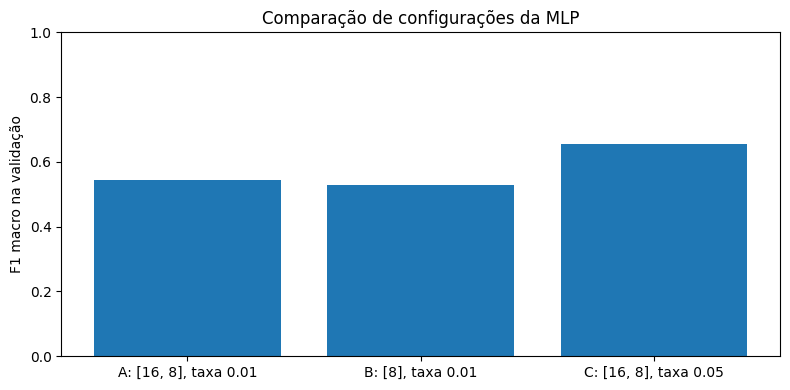

In [22]:
from sklearn.metrics import f1_score

# Armazenar o modelo de referência.
resultados = [{
    "nome": "A: [16, 8], taxa 0.01",
    "rede": rede,
    "historico": historico
}]

# Treinamento de configurações alternativas (momento e épocas constantes).
for nome, ocultas, taxa in [
    ("B: [8], taxa 0.01", [8], 0.01),
    ("C: [16, 8], taxa 0.05", [16, 8], 0.05)
]:
    print("\nTreinando", nome)

    modelo = MLP(
        [X_treino.shape[1]] + ocultas + [len(classes)],
        taxa_aprendizado=taxa,
        momento=0.9
    )

    registro = modelo.treinar(
        X_treino, y_treino,
        X_validacao, y_validacao,
        epocas=500
    )

    resultados.append({
        "nome": nome,
        "rede": modelo,
        "historico": registro
    })

# Avaliação dos modelos no conjunto de validação.
print("\nRESULTADOS NA VALIDAÇÃO")

for resultado in resultados:
    previsoes = resultado["rede"].prever(X_validacao)

    resultado["acuracia"] = np.mean(previsoes == y_validacao)
    resultado["f1"] = f1_score(
        y_validacao, previsoes,
        labels=np.arange(len(classes)),
        average="macro",
        zero_division=0
    )

    print(
        f'{resultado["nome"]} | '
        f'Acurácia: {resultado["acuracia"]:.1%} | '
        f'F1 macro: {resultado["f1"]:.3f}'
    )

# Seleção do melhor modelo com base na métrica F1 macro.
melhor = max(resultados, key=lambda resultado: resultado["f1"])
melhor_rede = melhor["rede"]
melhor_historico = melhor["historico"]

print("\nConfiguração escolhida:", melhor["nome"])

# Visualização da comparação de desempenho.
plt.figure(figsize=(8, 4))
plt.bar(
    [r["nome"] for r in resultados],
    [r["f1"] for r in resultados]
)
plt.ylabel("F1 macro na validação")
plt.ylim(0, 1)
plt.title("Comparação de configurações da MLP")
plt.tight_layout()
plt.show()

### 8. Avaliação final

Configuração: C: [16, 8], taxa 0.05
Acurácia no teste: 89.3%

Desempenho por classe:
                  precision    recall  f1-score   support

            Seco      0.500     0.704     0.585        27
Passado do ponto      0.400     0.421     0.410        19
          Maduro      0.658     0.803     0.723       122
      Semimaduro      0.696     0.447     0.545       123
           Verde      0.980     0.986     0.983       858

        accuracy                          0.893      1149
       macro avg      0.647     0.672     0.649      1149
    weighted avg      0.895     0.893     0.890      1149



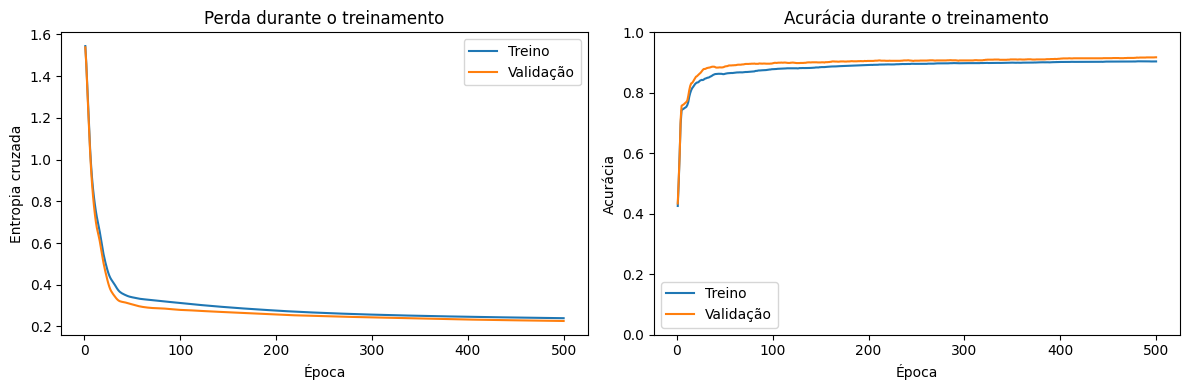

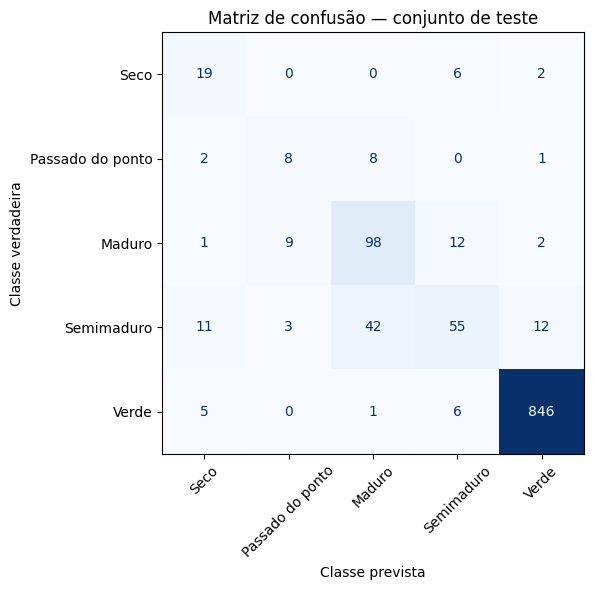

In [23]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

# Avaliação do melhor modelo no conjunto de teste.
previsoes = melhor_rede.prever(X_teste)

print("Configuração:", melhor["nome"])
print(f"Acurácia no teste: {accuracy_score(y_teste, previsoes):.1%}")

print("\nDesempenho por classe:")
print(classification_report(
    y_teste,
    previsoes,
    labels=np.arange(len(classes)),
    target_names=classes,
    digits=3,
    zero_division=0
))

# Curvas de aprendizado (perda e acurácia).
fig, eixos = plt.subplots(1, 2, figsize=(12, 4))
epocas_grafico = range(1, len(melhor_historico["perda_treino"]) + 1)

eixos[0].plot(
    epocas_grafico, melhor_historico["perda_treino"], label="Treino"
)
eixos[0].plot(
    epocas_grafico, melhor_historico["perda_validacao"], label="Validação"
)
eixos[0].set_title("Perda durante o treinamento")
eixos[0].set_xlabel("Época")
eixos[0].set_ylabel("Entropia cruzada")
eixos[0].legend()

eixos[1].plot(
    epocas_grafico, melhor_historico["acuracia_treino"], label="Treino"
)
eixos[1].plot(
    epocas_grafico, melhor_historico["acuracia_validacao"], label="Validação"
)
eixos[1].set_title("Acurácia durante o treinamento")
eixos[1].set_xlabel("Época")
eixos[1].set_ylabel("Acurácia")
eixos[1].set_ylim(0, 1)
eixos[1].legend()

plt.tight_layout()
plt.show()

# Matriz de confusão.
fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_teste,
    previsoes,
    labels=np.arange(len(classes)),
    display_labels=classes,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
    colorbar=False
)

ax.set_title("Matriz de confusão — conjunto de teste")
ax.set_xlabel("Classe prevista")
ax.set_ylabel("Classe verdadeira")
plt.tight_layout()
plt.show()

### 9. Conclusões

A MLP foi implementada com NumPy, usando seis características de cor por fruto.
A configuração escolhida possui duas camadas ocultas, com 16 e 8 neurônios, taxa de aprendizado de 0,05 e momento de 0,9, treinada por 500 épocas.
No teste, obteve 89,3% de acurácia e F1 macro de 0,649.
O melhor resultado ocorreu para frutos verdes; as principais dificuldades envolveram frutos semimaduros e passados do ponto.
O desequilíbrio entre classes e possíveis semelhanças de cor são limitações a investigar. Os resultados apresentados não demonstram, sozinhos, a causa dos erros.
O sistema depende das anotações para delimitar os frutos: ele classifica frutos já identificados, sem localizá-los automaticamente em uma foto nova.